In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from probcs.models.pattern_completion_model import PatternCompletionModel
from probcs.utils.utils import get_excitatory_images
from probcs.experiment_running.exc_experiment import center_surround_experiment, create_stimuli
import arviz as az
from sklearn.metrics.pairwise import cosine_similarity
from probcs.utils.utils import select_focus_images

seed = 42
rng = np.random.default_rng(seed)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
exc_images = get_excitatory_images()
vmin = np.min(exc_images)
vmax = np.max(exc_images)

In [3]:
G_dim = 2
G_prob = 1/G_dim
x_sigma = .1
I_sigma = 20
offset = 0
G_visual_nrows = G_dim
G_visual_ncols = 1
x_visual_nrows = G_dim
x_visual_ncols = 9
n_tune = 100
n_draws = 100
n_chains = 4
n_cores = 4

In [4]:
patterns = exc_images[[0, 8]]
cossim = cosine_similarity(patterns.reshape(patterns.shape[0], -1))

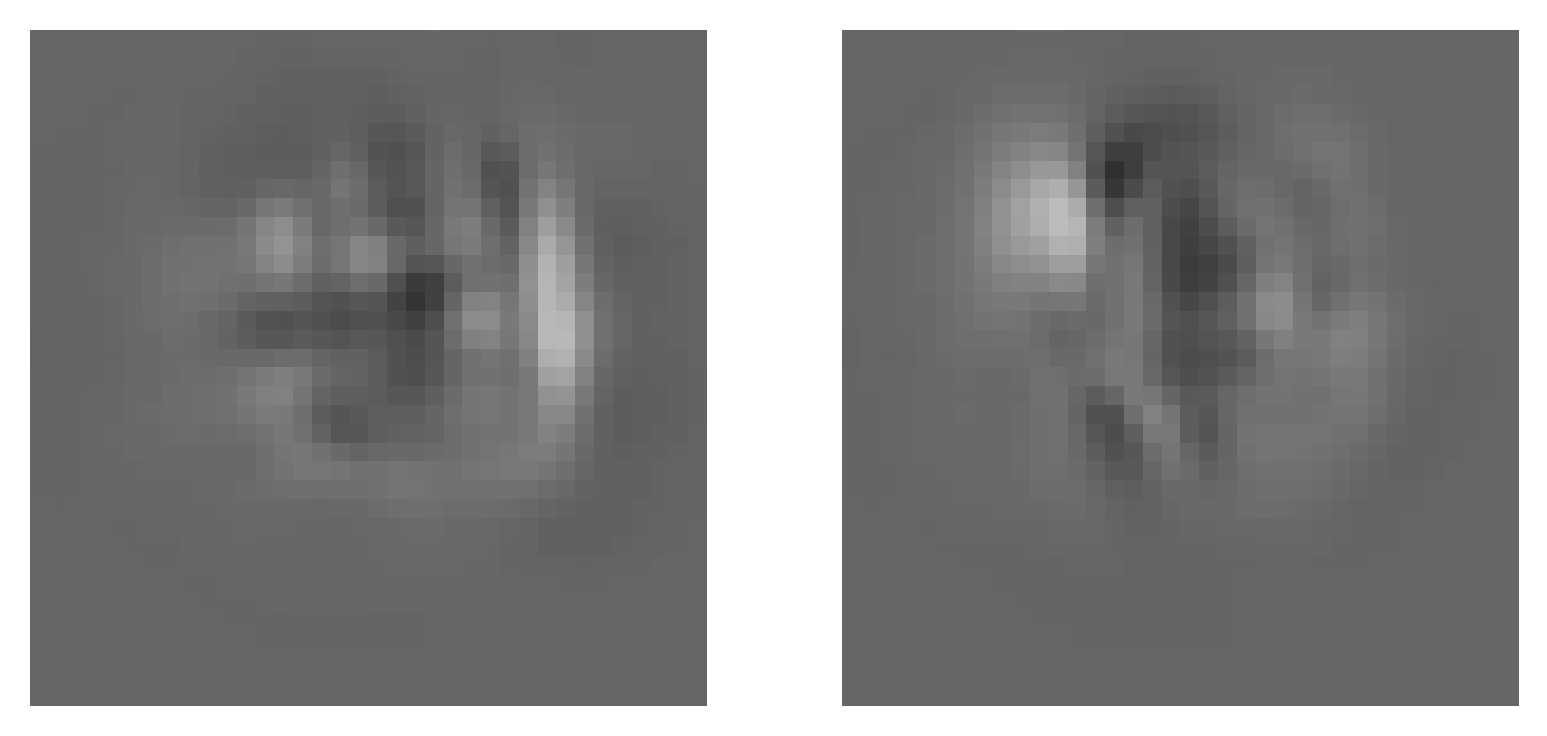

In [5]:
fig, axs = plt.subplots(1, G_dim, dpi=300)
for ax, pattern in zip(axs.flatten(), patterns):
    ax.imshow(pattern, cmap="gray", vmin=vmin, vmax=vmax)
    ax.axis("off")

In [6]:
cossim.shape

(2, 2)

Text(0.5, 1.0, 'Cos sim between assigned Gs')

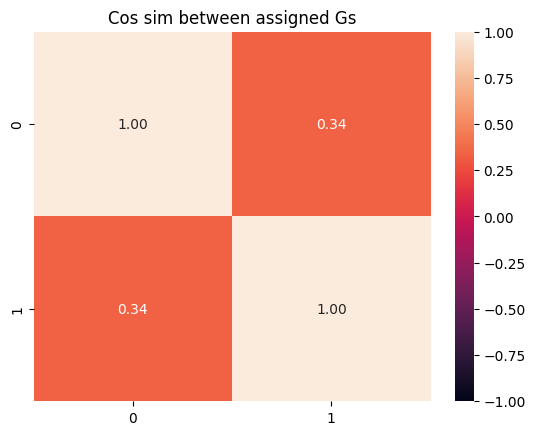

In [7]:
fig, ax = plt.subplots(dpi=100)
sns.heatmap(cossim, vmin=-1, vmax=1, annot=True, fmt=".2f", ax=ax)
ax.set_title("Cos sim between assigned Gs")

In [8]:
MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2, disrupting_pattern_indices = create_stimuli(patterns)

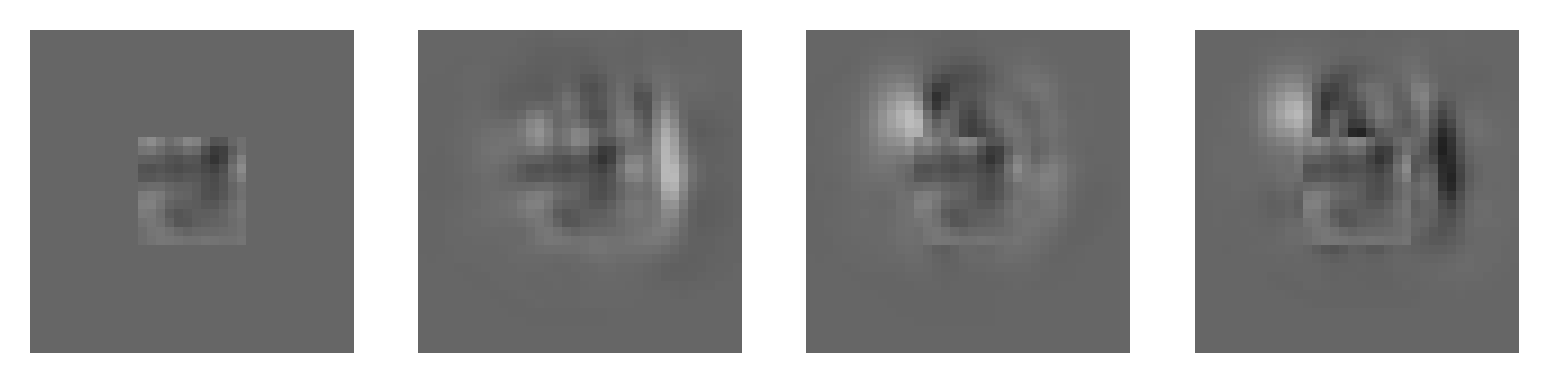

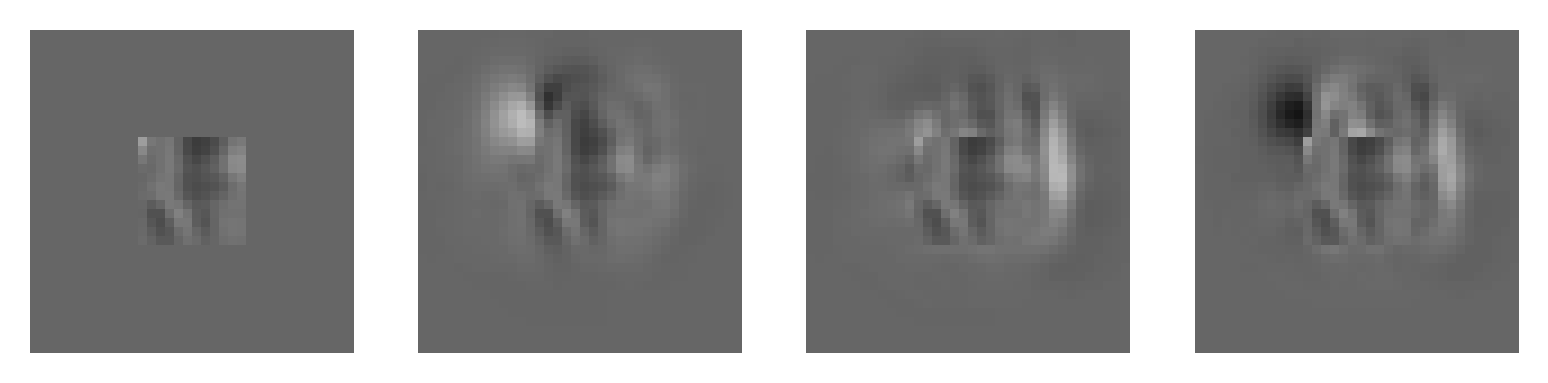

In [9]:
for MEI, completing_pattern, disrupting_pattern_1, disrupting_pattern_2 in zip(MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2):
    fig, axs = plt.subplots(1, 4, dpi=300)
    axs[0].imshow(MEI, cmap="gray", vmin=vmin, vmax=vmax)
    axs[0].axis("off")
    axs[1].imshow(completing_pattern, cmap="gray", vmin=vmin, vmax=vmax)
    axs[1].axis("off")
    axs[2].imshow(disrupting_pattern_1, cmap="gray", vmin=vmin, vmax=vmax)
    axs[2].axis("off")
    axs[3].imshow(disrupting_pattern_2, cmap="gray", vmin=vmin, vmax=vmax)
    axs[3].axis("off")

In [10]:
model = PatternCompletionModel(
    patterns=patterns,
    G_prob=G_prob,
    X_sigma=x_sigma,
    I_sigma=I_sigma,
    patterns_offset=offset,
)

In [11]:
all_idata = []
for MEI, completing_pattern, disrupting_pattern_1, disrupting_pattern_2 in zip(MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2):
    idata_set = []
    idata = model(
        image=MEI,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    idata = model(
        image=completing_pattern,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    idata = model(
        image=disrupting_pattern_1,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    idata = model(
        image=disrupting_pattern_2,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    all_idata.append(idata_set)


Only 100 samples in chain.
Multiprocess sampling (8 chains in 8 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 8 chains for 100 tune and 100 draw iterations (800 + 800 draws total) took 22 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Only 100 samples in chain.
Multiprocess sampling (8 chains in 8 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 8 chains for 100 tune and 100 draw iterations (800 + 800 draws total) took 38 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Only 100 samples in chain.
Multiprocess sampling (8 chains in 8 jobs)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


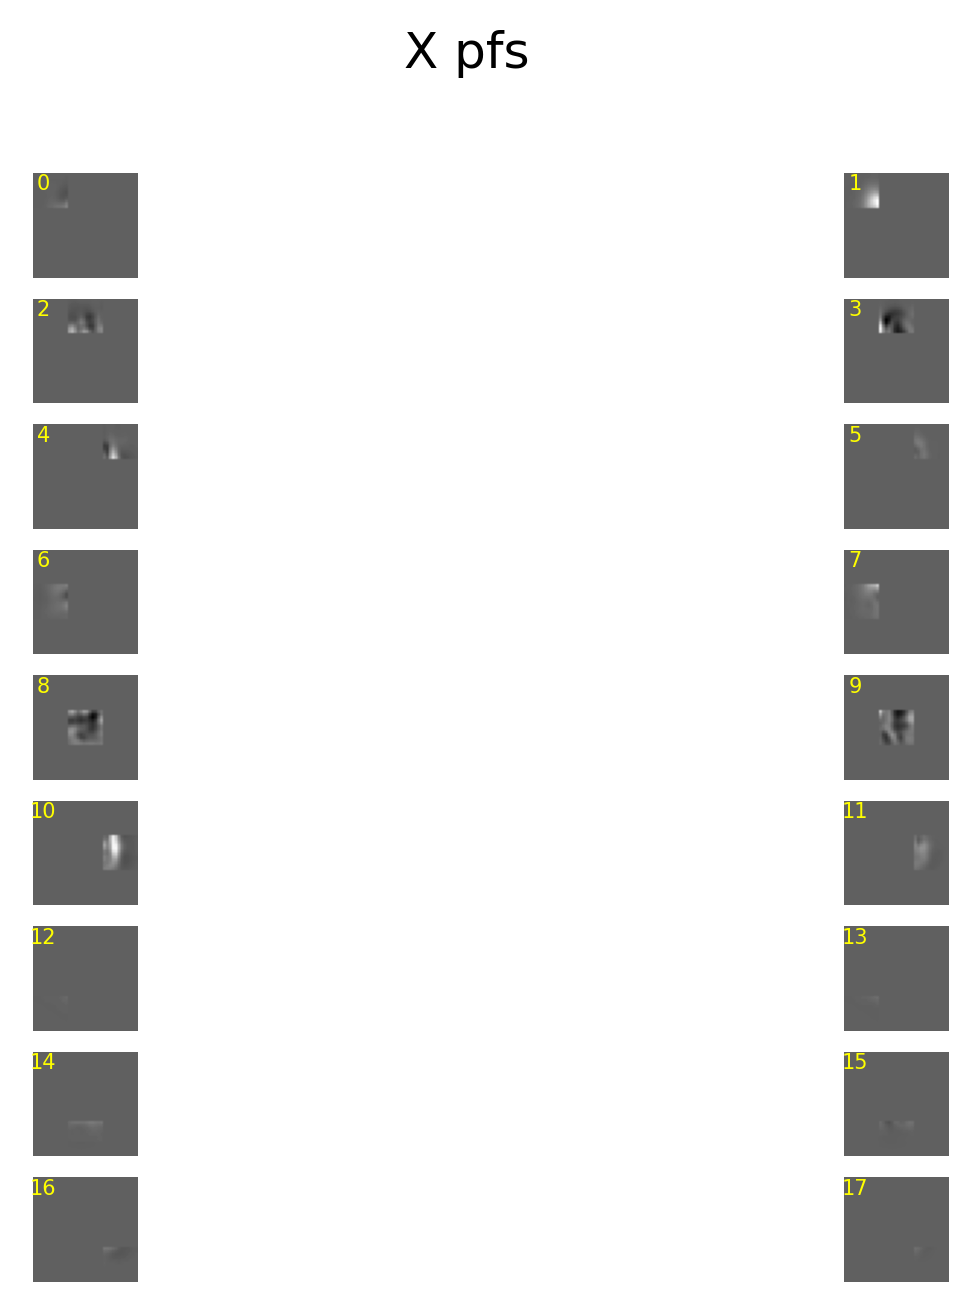

In [ ]:
x_pfs = model.visualize_learned_X(9, G_dim)

In [ ]:
disrupting_pattern_indices

[1, 0]

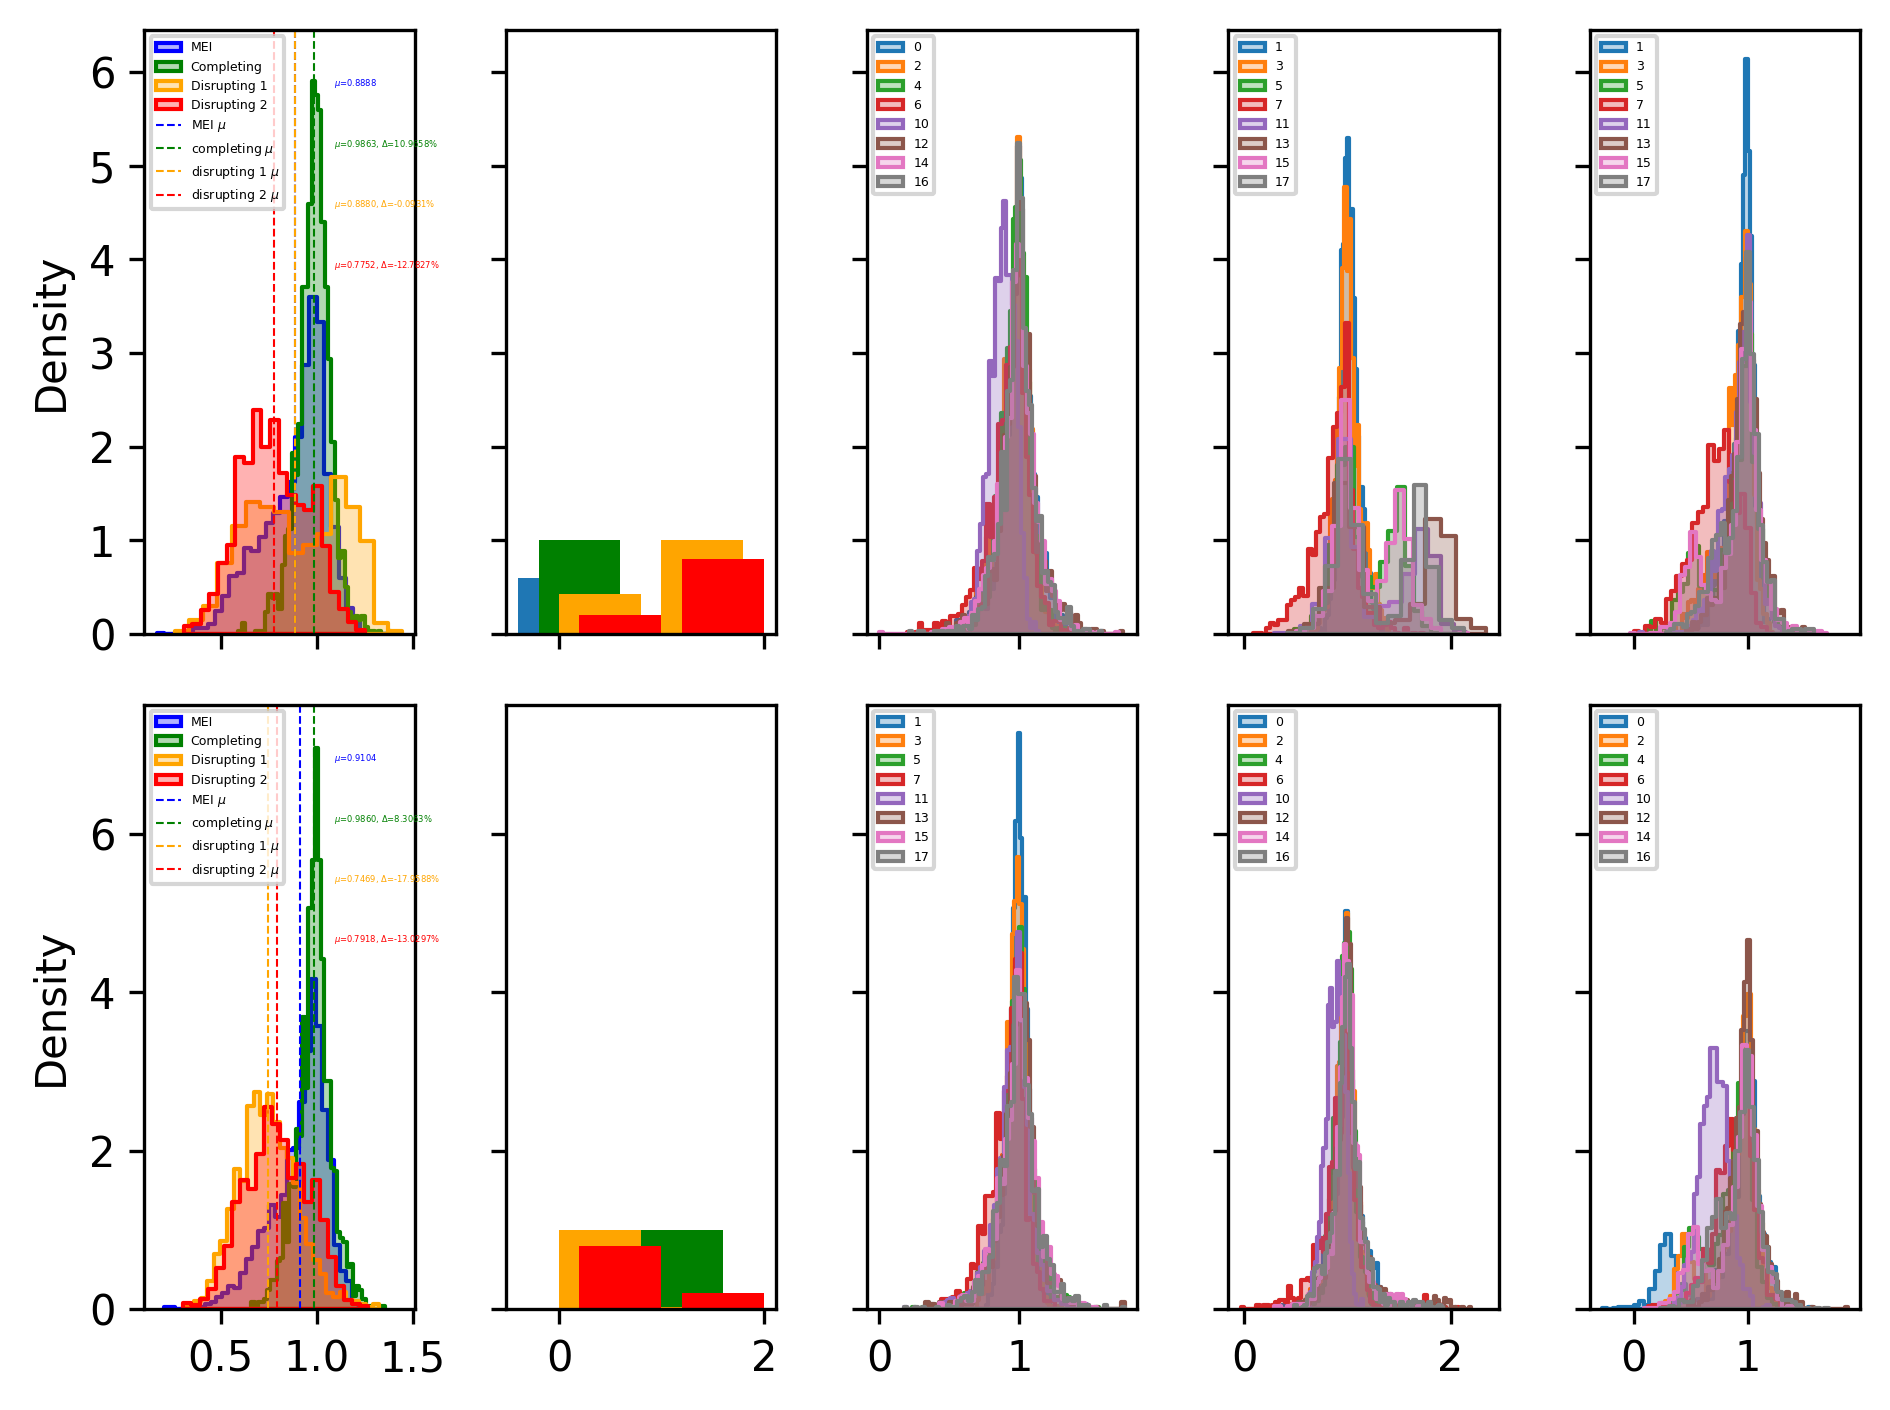

In [ ]:
fig, axs = plt.subplots(2, 5, dpi=300, tight_layout=True, sharex='col', sharey='row')
possible_center_x_ids = [4 * G_dim + i for i in range(G_dim)]
for idx, (ax_set, idata_set, disrupting_pattern_idx) in enumerate(zip(axs, all_idata, disrupting_pattern_indices)):
    center_x_id = 4 * G_dim + idx
    # i for i in range(idx, G_dim)
    completing_surround_x_ids = [i for i in range(idx, 9*G_dim, G_dim) if i != center_x_id]

    disrupting_surround_x_ids = [i for i in range(disrupting_pattern_idx, 9*G_dim, G_dim) if i not in possible_center_x_ids]
    # idata['posterior']['X'].data.shape = (n_chains, n_samples, n_x_dims)
    mei_idata = idata_set[0]
    completing_idata = idata_set[1]
    disrupting_1_idata = idata_set[2]
    disrupting_2_idata = idata_set[3]

    mei_x_samples = mei_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
    mei_x_mean = mei_x_samples.mean()
    sns.histplot(
        mei_x_samples,
        ax=ax_set[0],
        stat="density",
        color="blue",
        element="step",
        alpha=0.3,
        label="MEI"
    )

    # mei_idata["posterior"]["G"].data.shape = (n_chains, n_samples, n_G_dims)
    mei_g_samples = mei_idata["posterior"]["G"].data.mean(axis=0).mean(axis=0)
    # mei_g_samples.shape = (n_G_dims,)
    # plot a bar plot of the Gs
    ax_set[1].bar(
        x=np.arange(G_dim),
        height=mei_g_samples,
        label="MEI"
    )

    colors = plt.cm.tab10(range(len(completing_surround_x_ids)))
    for completing_surround_index, completing_surround_x_id in enumerate(completing_surround_x_ids):
        completing_surround_x_samples = completing_idata["posterior"]["X"].data[:, :, completing_surround_x_id].flatten()
        sns.histplot(
            completing_surround_x_samples,
            ax=ax_set[2],
            stat="density",
            color=colors[completing_surround_index],
            element="step",
            alpha=0.3,
            label=f"{completing_surround_x_id}"
        )
        ax_set[2].legend(prop={'size': 3}, loc="upper left")

    completing_x_samples = completing_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
    completing_x_mean = completing_x_samples.mean()
    completing_perc_diff = (completing_x_mean - mei_x_mean) / mei_x_mean * 100
    sns.histplot(
        completing_x_samples,
        ax=ax_set[0],
        stat="density",
        color="green",
        element="step",
        alpha=0.3,
        label="Completing"
    )

    completing_g_samples = completing_idata["posterior"]["G"].data.mean(axis=0).mean(axis=0)
    ax_set[1].bar(
        x=np.arange(G_dim) + 0.2,
        height=completing_g_samples,
        color="green",
        label="Completing"
    )

    disrupting_1_x_samples = disrupting_1_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
    disrupting_1_x_mean = disrupting_1_x_samples.mean()
    disrupting_1_perc_diff = (disrupting_1_x_mean - mei_x_mean) / mei_x_mean * 100
    sns.histplot(
        disrupting_1_x_samples,
        ax=ax_set[0],
        stat="density",
        color="orange",
        element="step",
        alpha=0.3,
        label="Disrupting 1"
    )

    disrupting_1_g_samples = disrupting_1_idata["posterior"]["G"].data.mean(axis=0).mean(axis=0)
    ax_set[1].bar(
        x=np.arange(G_dim) + 0.4,
        height=disrupting_1_g_samples,
        color="orange",
        label="Disrupting 1"
    )

    disrupting_2_x_samples = disrupting_2_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
    disrupting_2_x_mean = disrupting_2_x_samples.mean()
    disrupting_2_perc_diff = (disrupting_2_x_mean - mei_x_mean) / mei_x_mean * 100
    sns.histplot(
        disrupting_2_x_samples,
        ax=ax_set[0],
        stat="density",
        color="red",
        element="step",
        alpha=0.3,
        label="Disrupting 2"
    )

    disrupting_2_g_samples = disrupting_2_idata["posterior"]["G"].data.mean(axis=0).mean(axis=0)
    ax_set[1].bar(
        x=np.arange(G_dim) + 0.6,
        height=disrupting_2_g_samples,
        color="red",
        label="Disrupting 2"
    )

    colors = plt.cm.tab10(range(len(disrupting_surround_x_ids)))
    for disrupting_surround_index, disrupting_surround_x_id in enumerate(disrupting_surround_x_ids):
        disrupting_1_surround_x_samples = disrupting_1_idata["posterior"]["X"].data[:, :, disrupting_surround_x_id].flatten()
        sns.histplot(
            disrupting_1_surround_x_samples,
            ax=ax_set[3],
            stat="density",
            color=colors[disrupting_surround_index],
            element="step",
            alpha=0.3,
            label=f"{disrupting_surround_x_id}"
        )
        ax_set[3].legend(prop={'size': 3}, loc="upper left")
        disrupting_2_surround_x_samples = disrupting_2_idata["posterior"]["X"].data[:, :, disrupting_surround_x_id].flatten()
        sns.histplot(
            disrupting_2_surround_x_samples,
            ax=ax_set[4],
            stat="density",
            color=colors[disrupting_surround_index],
            element="step",
            alpha=0.3,
            label=f"{disrupting_surround_x_id}"
        )
        ax_set[4].legend(prop={'size': 3}, loc="upper left")
    ax_set[0].text(0.7, 0.9, f"$\mu$={mei_x_mean:.4f}", size=2, ha="left", va="bottom", transform=ax_set[0].transAxes, color='blue')
    ax_set[0].text(0.7, 0.8, f"$\mu$={completing_x_mean:.4f}, $\Delta$={completing_perc_diff:.4f}%", size=2, ha="left", va="bottom", transform=ax_set[0].transAxes, color='green')
    ax_set[0].text(0.7, 0.7, f"$\mu$={disrupting_1_x_mean:.4f}, $\Delta$={disrupting_1_perc_diff:.4f}%", size=2, ha="left", va="bottom", transform=ax_set[0].transAxes, color='orange')
    ax_set[0].text(0.7, 0.6, f"$\mu$={disrupting_2_x_mean:.4f}, $\Delta$={disrupting_2_perc_diff:.4f}%", size=2, ha="left", va="bottom", transform=ax_set[0].transAxes, color='red')

    ax_set[0].axvline(mei_x_mean, color="blue", linestyle="--", linewidth=0.5, label="MEI $\mu$")
    ax_set[0].axvline(completing_x_mean, color="green", linestyle="--", linewidth=0.5, label="completing $\mu$")
    ax_set[0].axvline(disrupting_1_x_mean, color="orange", linestyle="--", linewidth=0.5, label="disrupting 1 $\mu$")
    ax_set[0].axvline(disrupting_2_x_mean, color="red", linestyle="--", linewidth=0.5, label="disrupting 2 $\mu$")
    ax_set[0].legend(prop={'size': 3}, loc="upper left")


[0, 2, 4, 6, 9, 10, 12, 14, 16]
[1, 3, 5, 7, 8, 11, 13, 15, 17]


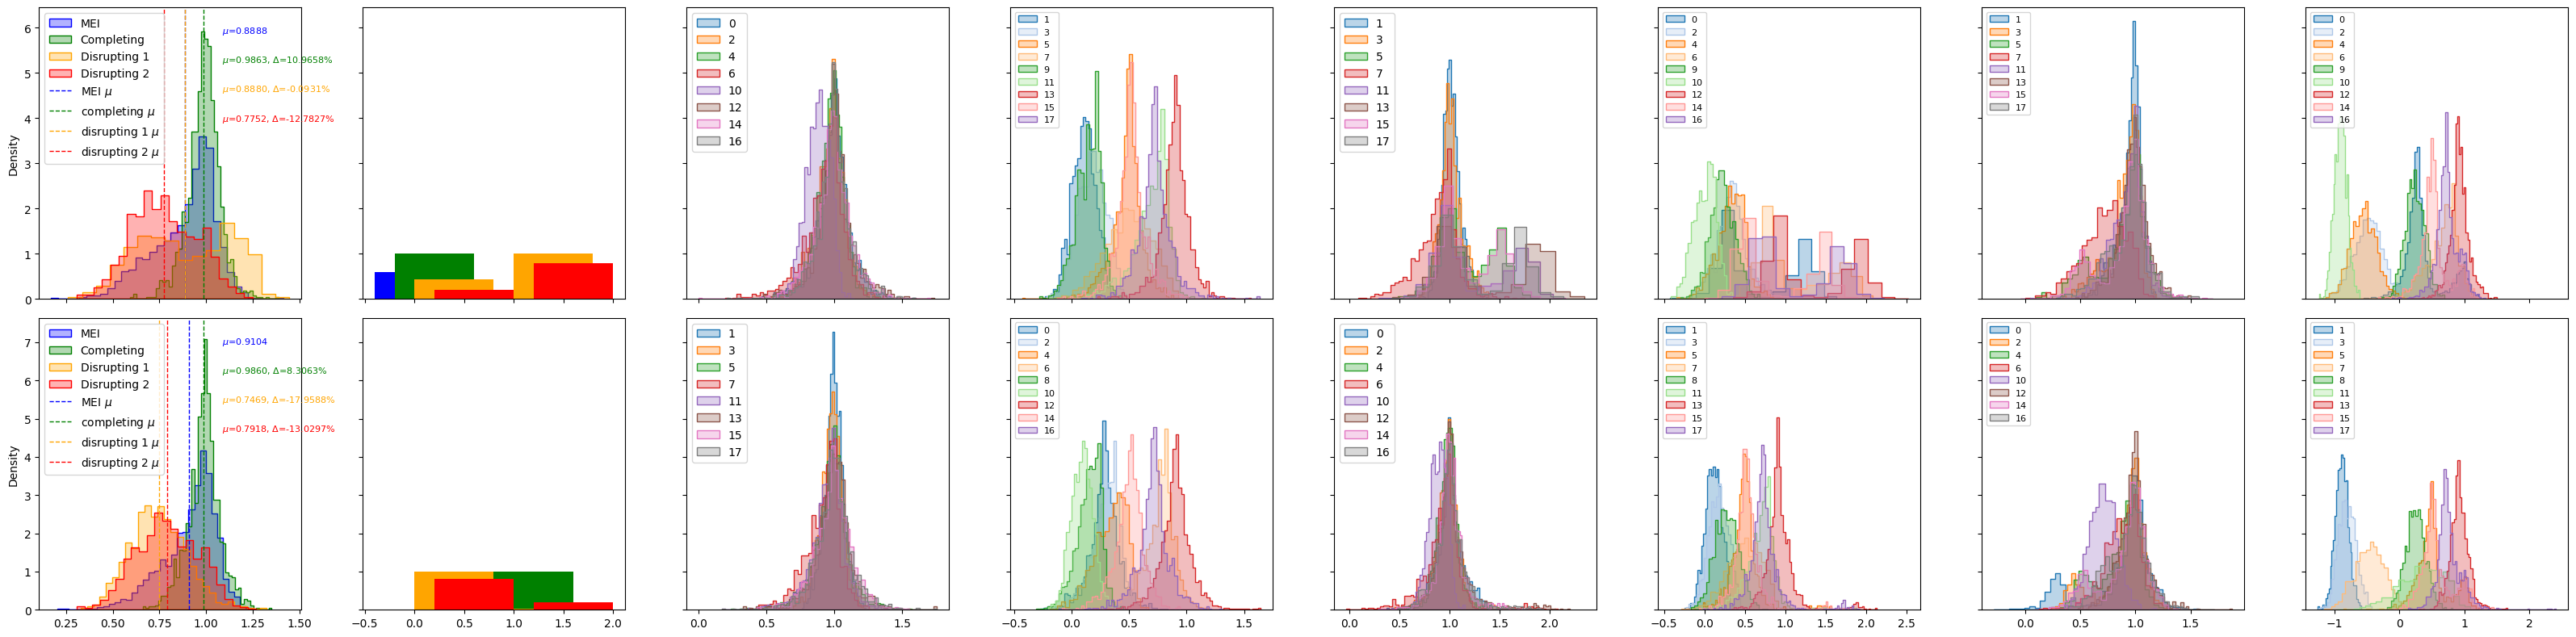

In [ ]:
fig, axs = plt.subplots(2, 8, figsize=(8*4, 2*4), tight_layout=True, sharex='col', sharey='row')
possible_center_x_ids = [4 * G_dim + i for i in range(G_dim)]
for idx, (ax_set, idata_set, disrupting_pattern_idx) in enumerate(zip(axs, all_idata, disrupting_pattern_indices)):
    center_x_id = 4 * G_dim + idx
    # i for i in range(idx, G_dim)
    completing_surround_x_ids = [i for i in range(idx, 9*G_dim, G_dim) if i != center_x_id]
    # complement of completing_surround_x_ids
    not_completing_surround_x_ids = [i for i in range(9 * G_dim) if (i not in completing_surround_x_ids) and (i != center_x_id)]
    disrupting_surround_x_ids = [i for i in range(disrupting_pattern_idx, 9*G_dim, G_dim) if i not in possible_center_x_ids]
    # complement of disrupting_surround_x_ids
    not_disrupting_surround_x_ids = [i for i in range(9 * G_dim) if (i not in disrupting_surround_x_ids) and (i != center_x_id)]
    print(not_disrupting_surround_x_ids)
    
    # idata['posterior']['X'].data.shape = (n_chains, n_samples, n_x_dims)
    mei_idata = idata_set[0]
    completing_idata = idata_set[1]
    disrupting_1_idata = idata_set[2]
    disrupting_2_idata = idata_set[3]

    mei_x_samples = mei_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
    mei_x_mean = mei_x_samples.mean()
    sns.histplot(
        mei_x_samples,
        ax=ax_set[0],
        stat="density",
        color="blue",
        element="step",
        alpha=0.3,
        label="MEI"
    )

    # mei_idata["posterior"]["G"].data.shape = (n_chains, n_samples, n_G_dims)
    mei_g_samples = mei_idata["posterior"]["G"].data.mean(axis=0).mean(axis=0)
    # mei_g_samples.shape = (n_G_dims,)
    # plot a bar plot of the Gs
    ax_set[1].bar(
        x=np.arange(G_dim),
        height=mei_g_samples,
        color="blue",
        label="MEI"
    )

    colors = plt.cm.tab10(range(len(completing_surround_x_ids)))
    for completing_surround_index, completing_surround_x_id in enumerate(completing_surround_x_ids):
        completing_surround_x_samples = completing_idata["posterior"]["X"].data[:, :, completing_surround_x_id].flatten()
        sns.histplot(
            completing_surround_x_samples,
            ax=ax_set[2],
            stat="density",
            color=colors[completing_surround_index],
            element="step",
            alpha=0.3,
            label=f"{completing_surround_x_id}"
        )
        ax_set[2].legend(prop={'size': 10}, loc="upper left")


    colors = plt.cm.tab20(range(len(not_completing_surround_x_ids)))
    for not_completing_surround_index, not_completing_surround_x_id in enumerate(not_completing_surround_x_ids):
        not_completing_surround_x_samples = completing_idata["posterior"]["X"].data[:, :, not_completing_surround_x_id].flatten()
        sns.histplot(
            not_completing_surround_x_samples,
            ax=ax_set[3],
            stat="density",
            color=colors[not_completing_surround_index],
            element="step",
            alpha=0.3,
            label=f"{not_completing_surround_x_id}"
        )
        ax_set[3].legend(prop={'size': 8}, loc="upper left")



    completing_x_samples = completing_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
    completing_x_mean = completing_x_samples.mean()
    completing_perc_diff = (completing_x_mean - mei_x_mean) / mei_x_mean * 100
    sns.histplot(
        completing_x_samples,
        ax=ax_set[0],
        stat="density",
        color="green",
        element="step",
        alpha=0.3,
        label="Completing"
    )

    completing_g_samples = completing_idata["posterior"]["G"].data.mean(axis=0).mean(axis=0)
    ax_set[1].bar(
        x=np.arange(G_dim) + 0.2,
        height=completing_g_samples,
        color="green",
        label="Completing"
    )

    disrupting_1_x_samples = disrupting_1_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
    disrupting_1_x_mean = disrupting_1_x_samples.mean()
    disrupting_1_perc_diff = (disrupting_1_x_mean - mei_x_mean) / mei_x_mean * 100
    sns.histplot(
        disrupting_1_x_samples,
        ax=ax_set[0],
        stat="density",
        color="orange",
        element="step",
        alpha=0.3,
        label="Disrupting 1"
    )

    disrupting_1_g_samples = disrupting_1_idata["posterior"]["G"].data.mean(axis=0).mean(axis=0)
    ax_set[1].bar(
        x=np.arange(G_dim) + 0.4,
        height=disrupting_1_g_samples,
        color="orange",
        label="Disrupting 1"
    )

    disrupting_2_x_samples = disrupting_2_idata["posterior"]["X"].data[:, :, center_x_id].flatten()
    disrupting_2_x_mean = disrupting_2_x_samples.mean()
    disrupting_2_perc_diff = (disrupting_2_x_mean - mei_x_mean) / mei_x_mean * 100
    sns.histplot(
        disrupting_2_x_samples,
        ax=ax_set[0],
        stat="density",
        color="red",
        element="step",
        alpha=0.3,
        label="Disrupting 2"
    )

    disrupting_2_g_samples = disrupting_2_idata["posterior"]["G"].data.mean(axis=0).mean(axis=0)
    ax_set[1].bar(
        x=np.arange(G_dim) + 0.6,
        height=disrupting_2_g_samples,
        color="red",
        label="Disrupting 2"
    )

    colors = plt.cm.tab10(range(len(disrupting_surround_x_ids)))
    for disrupting_surround_index, disrupting_surround_x_id in enumerate(disrupting_surround_x_ids):
        disrupting_1_surround_x_samples = disrupting_1_idata["posterior"]["X"].data[:, :, disrupting_surround_x_id].flatten()
        sns.histplot(
            disrupting_1_surround_x_samples,
            ax=ax_set[4],
            stat="density",
            color=colors[disrupting_surround_index],
            element="step",
            alpha=0.3,
            label=f"{disrupting_surround_x_id}"
        )
        ax_set[4].legend(prop={'size': 10}, loc="upper left")
        disrupting_2_surround_x_samples = disrupting_2_idata["posterior"]["X"].data[:, :, disrupting_surround_x_id].flatten()
        sns.histplot(
            disrupting_2_surround_x_samples,
            ax=ax_set[6],
            stat="density",
            color=colors[disrupting_surround_index],
            element="step",
            alpha=0.3,
            label=f"{disrupting_surround_x_id}"
        )
        ax_set[6].legend(prop={'size': 8}, loc="upper left")

    colors = plt.cm.tab20(range(len(not_disrupting_surround_x_ids)))
    for not_disrupting_surround_index, not_disrupting_surround_x_id in enumerate(not_disrupting_surround_x_ids):
        not_disrupting_1_surround_x_samples = disrupting_1_idata["posterior"]["X"].data[:, :, not_disrupting_surround_x_id].flatten()
        sns.histplot(
            not_disrupting_1_surround_x_samples,
            ax=ax_set[5],
            stat="density",
            color=colors[not_disrupting_surround_index],
            element="step",
            alpha=0.3,
            label=f"{not_disrupting_surround_x_id}"
        )
        ax_set[5].legend(prop={'size': 8}, loc="upper left")
        not_disrupting_2_surround_x_samples = disrupting_2_idata["posterior"]["X"].data[:, :, not_disrupting_surround_x_id].flatten()
        sns.histplot(
            not_disrupting_2_surround_x_samples,
            ax=ax_set[7],
            stat="density",
            color=colors[not_disrupting_surround_index],
            element="step",
            alpha=0.3,
            label=f"{not_disrupting_surround_x_id}"
        )
        ax_set[7].legend(prop={'size': 8}, loc="upper left")

    
    ax_set[0].text(0.7, 0.9, f"$\mu$={mei_x_mean:.4f}", size=8, ha="left", va="bottom", transform=ax_set[0].transAxes, color='blue')
    ax_set[0].text(0.7, 0.8, f"$\mu$={completing_x_mean:.4f}, $\Delta$={completing_perc_diff:.4f}%", size=8, ha="left", va="bottom", transform=ax_set[0].transAxes, color='green')
    ax_set[0].text(0.7, 0.7, f"$\mu$={disrupting_1_x_mean:.4f}, $\Delta$={disrupting_1_perc_diff:.4f}%", size=8, ha="left", va="bottom", transform=ax_set[0].transAxes, color='orange')
    ax_set[0].text(0.7, 0.6, f"$\mu$={disrupting_2_x_mean:.4f}, $\Delta$={disrupting_2_perc_diff:.4f}%", size=8, ha="left", va="bottom", transform=ax_set[0].transAxes, color='red')

    ax_set[0].axvline(mei_x_mean, color="blue", linestyle="--", linewidth=1, label="MEI $\mu$")
    ax_set[0].axvline(completing_x_mean, color="green", linestyle="--", linewidth=1, label="completing $\mu$")
    ax_set[0].axvline(disrupting_1_x_mean, color="orange", linestyle="--", linewidth=1, label="disrupting 1 $\mu$")
    ax_set[0].axvline(disrupting_2_x_mean, color="red", linestyle="--", linewidth=1, label="disrupting 2 $\mu$")
    ax_set[0].legend(prop={'size': 10}, loc="upper left")
